# Brain Tumour MRI Classification — Part 1: Baseline
**Unit:** CIS143-6 Applications of AI  
**Dataset:** Brain Tumour MRI (Kaggle — masoudnickparvar)  
**Classes:** Glioma · Meningioma · No Tumour · Pituitary  

## 1. Environment Setup

In [1]:
import os
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0-dev0+selfbuilt


In [2]:
# Confirm GPU is available
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus if gpus else "NONE — enable GPU in Runtime settings")

# Detect environment
import google.colab as _colab_mod
IN_COLAB = not getattr(_colab_mod, '_IS_LOCAL_STUB', False)

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
else:
    DRIVE_DIR = Path('../models')

DRIVE_DIR.mkdir(parents=True, exist_ok=True)
print("Model folder:", DRIVE_DIR)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model folder: ../models


## 2. Dataset Download & Organisation

In [3]:
import kagglehub

if IN_COLAB:
    DATA_DIR = Path('/content/brain_tumour_data')
    if not DATA_DIR.exists():
        print("Downloading dataset from Kaggle...")
        raw_path = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
        shutil.copytree(raw_path, DATA_DIR)
        drive_dataset = DRIVE_DIR / 'dataset'
        if not drive_dataset.exists():
            shutil.copytree(raw_path, drive_dataset)
            print("Persisted to Google Drive.")
        print("Done.")
    else:
        print("Dataset already cached at", DATA_DIR)
else:
    DATA_DIR = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
    print("Dataset at:", DATA_DIR)

print("Data directory:", DATA_DIR)

Dataset at: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2
Data directory: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [ ]:
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TRAIN_DIR = DATA_DIR / 'Training'

counts = {}
for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    counts[cls] = len(list(cls_dir.glob('*.jpg')))

count_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Images'])
count_df['Percentage'] = (count_df['Images'] / count_df['Images'].sum() * 100).round(1)
print(count_df)
print(f"\nTotal training images: {count_df['Images'].sum()}")

            Images  Percentage
glioma        1400        25.0
meningioma    1400        25.0
notumor       1400        25.0
pituitary     1400        25.0

Total training images: 5600


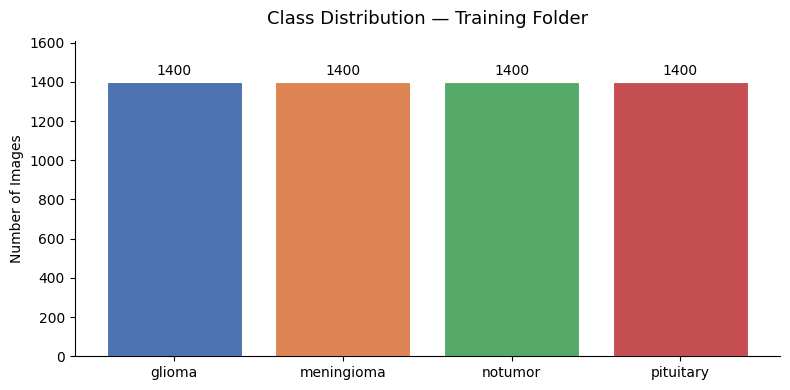

In [5]:
colours = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.keys(), counts.values(), color=colours, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
ax.set_title('Class Distribution — Training Folder', fontsize=13, pad=12)
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(counts.values()) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

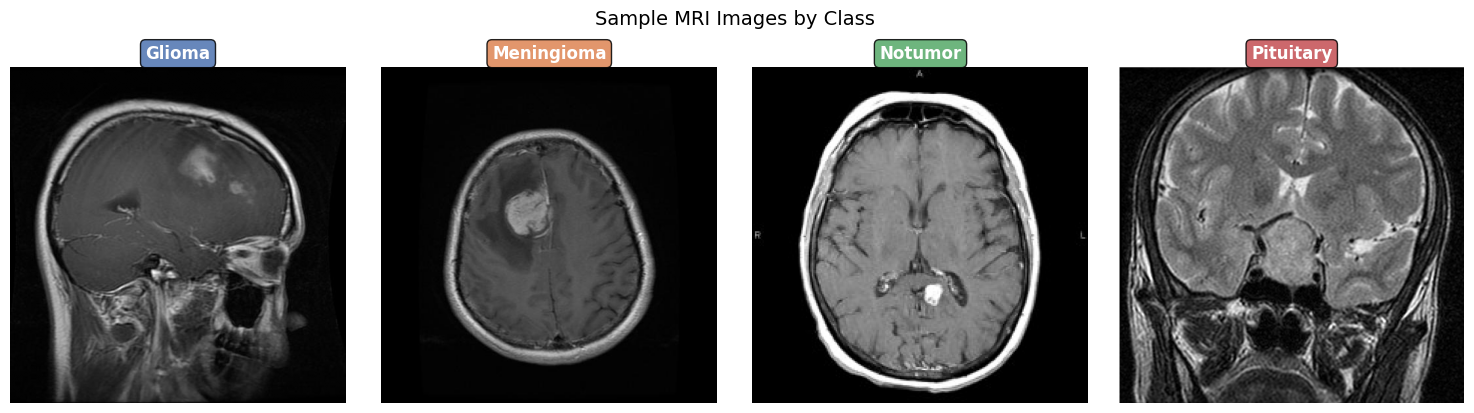

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, cls, colour in zip(axes, CLASSES, colours):
    img_path = next((TRAIN_DIR / cls).glob('*.jpg'))
    ax.imshow(Image.open(img_path), cmap='gray')
    ax.set_title(cls.capitalize(), fontsize=12, color='white',
                 fontweight='bold', pad=6,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=colour, alpha=0.85))
    ax.axis('off')
plt.suptitle('Sample MRI Images by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [ ]:
records = []
for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total images: {len(df)}")
print(df['label'].value_counts())

Total images: 5600
label
pituitary     1400
meningioma    1400
notumor       1400
glioma        1400
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print("\nPer-class split counts:")
split_summary = pd.DataFrame({
    'Train': train_df['label'].value_counts(),
    'Val':   val_df['label'].value_counts(),
    'Test':  test_df['label'].value_counts(),
})
print(split_summary)

overlap = set(train_df['filepath']) & set(val_df['filepath']) & set(test_df['filepath'])
print(f"\nFile overlap across splits: {len(overlap)} (expected 0)")

Train: 3920  |  Val: 840  |  Test: 840

Per-class split counts:
            Train  Val  Test
label                       
glioma        980  210   210
meningioma    980  210   210
notumor       980  210   210
pituitary     980  210   210

File overlap across splits: 0 (expected 0)


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    zoom_range=0.10,
    horizontal_flip=True,
    width_shift_range=0.10,
    height_shift_range=0.10,
)
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Class index mapping:", train_gen.class_indices)

Found 3920 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Class index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 4. Baseline CNN Model

In [ ]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='baseline_cnn')

    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

I0000 00:00:1779022926.613660      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14534 MB memory:  -> device: 0, name: AMD Radeon Graphics, pci bus id: 0000:03:00.0


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,700 (84.86 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS = 20

history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1,
)

Epoch 1/20
  2/123 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2891 - loss: 1.4149  

I0000 00:00:1779022955.953826     226 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 218ms/step - accuracy: 0.6031 - loss: 0.9295 - val_accuracy: 0.7048 - val_loss: 0.7523
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.7319 - loss: 0.6732 - val_accuracy: 0.7369 - val_loss: 0.7036
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.7574 - loss: 0.6085 - val_accuracy: 0.6274 - val_loss: 1.0259
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - accuracy: 0.7724 - loss: 0.5613 - val_accuracy: 0.7333 - val_loss: 0.6847
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.8031 - loss: 0.5167 - val_accuracy: 0.6750 - val_loss: 0.8174
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.8122 - loss: 0.4864 - val_accuracy: 0.7893 - val_loss: 0.5072
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.8293 - loss: 0.4520 - val_accuracy: 0.8095 - val_loss: 0.4964
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.8194 - loss: 0.4537 - val

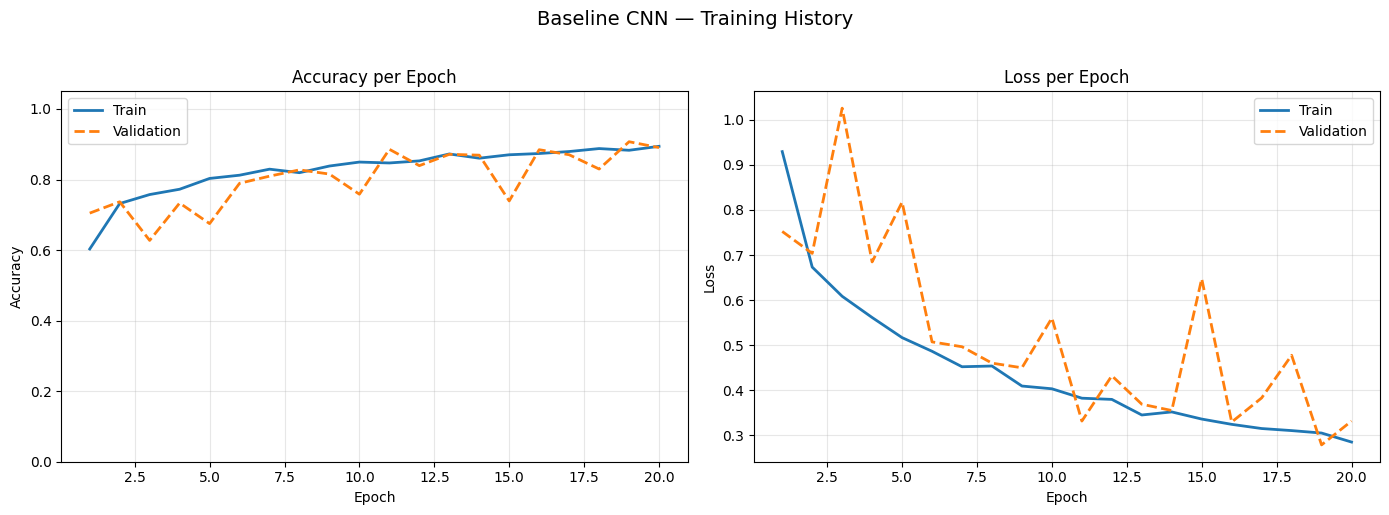

In [12]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation',
         linewidth=2, linestyle='--')
ax1.set_title('Accuracy per Epoch', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history.history['loss'], label='Train', linewidth=2)
ax2.plot(epochs_range, history.history['val_loss'], label='Validation',
         linewidth=2, linestyle='--')
ax2.set_title('Loss per Epoch', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Baseline CNN — Training History', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Evaluation

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

test_gen.reset()
y_pred_probs = baseline_model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Test Accuracy : 0.8583
Test Loss     : 0.3512

Classification Report:
              precision    recall  f1-score   support

      glioma     0.9006    0.7333    0.8084       210
  meningioma     0.8377    0.7619    0.7980       210
     notumor     0.8313    0.9857    0.9020       210
   pituitary     0.8734    0.9524    0.9112       210

    accuracy                         0.8583       840
   macro avg     0.8607    0.8583    0.8549       840
weighted avg     0.8607    0.8583    0.8549       840



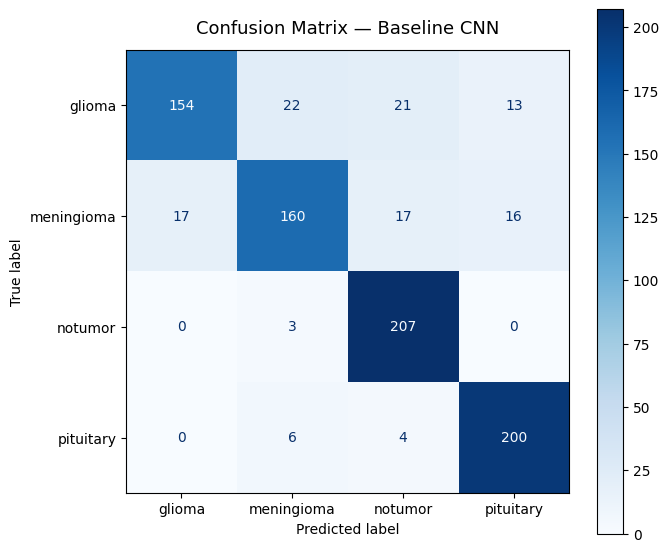

In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Baseline CNN', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 6. Error Analysis

Total misclassified: 119 / 840 (14.2%)


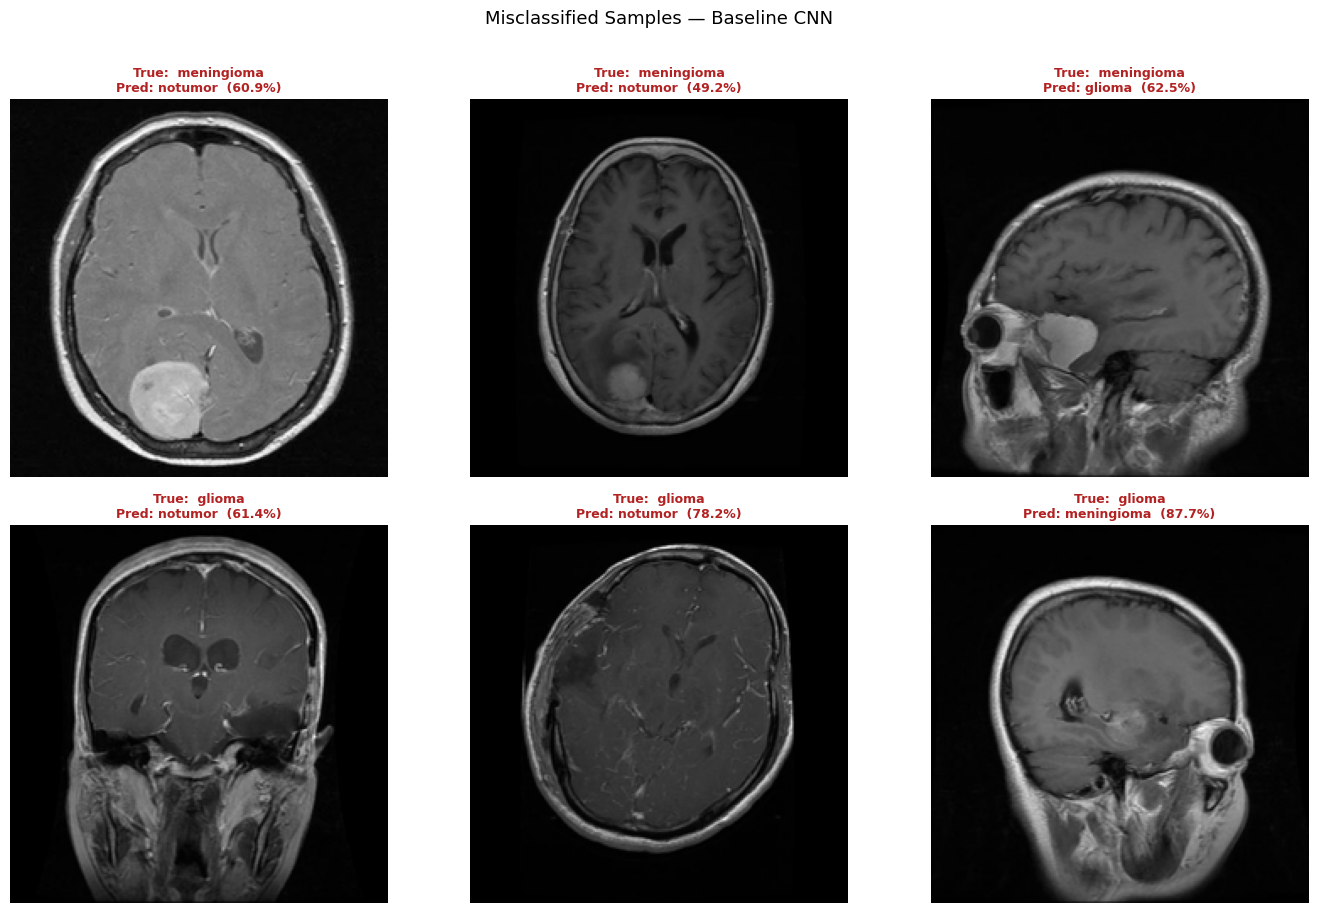

In [15]:
filepaths = test_gen.filepaths

misclassified = [
    (filepaths[i], y_true[i], y_pred[i], y_pred_probs[i].max())
    for i in range(len(y_true))
    if y_true[i] != y_pred[i]
]
print(f"Total misclassified: {len(misclassified)} / {len(y_true)} "
      f"({len(misclassified)/len(y_true)*100:.1f}%)")

samples = random.sample(misclassified, min(6, len(misclassified)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (path, true_idx, pred_idx, conf) in zip(axes.flat, samples):
    img = Image.open(path).resize((224, 224))
    ax.imshow(img, cmap='gray')
    ax.set_title(
        f"True:  {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}  ({conf:.1%})",
        fontsize=9, color='firebrick', fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Misclassified Samples — Baseline CNN', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
save_path = str(DRIVE_DIR / 'baseline_cnn.keras')
baseline_model.save(save_path)
print("Model saved to:", save_path)

Model saved to: ../models/baseline_cnn.keras
